
# Davis Club - Updated With 2 Mode Analysis

Davis Southern Club Women

Shows how to make unipartite projections of the graph and compute the
properties of those graphs.

These data were collected by Davis et al. in the 1930s.
They represent observed attendance at 14 social events by 18 Southern women.
The graph is bipartite (clubs, women).


Biadjacency matrix
<Compressed Sparse Row sparse array of dtype 'int64'
	with 89 stored elements and shape (18, 14)>
  Coords	Values
  (0, 0)	1
  (0, 1)	1
  (0, 2)	1
  (0, 3)	1
  (0, 4)	1
  (0, 5)	1
  (0, 7)	1
  (0, 8)	1
  (1, 0)	1
  (1, 1)	1
  (1, 2)	1
  (1, 4)	1
  (1, 5)	1
  (1, 6)	1
  (1, 7)	1
  (2, 1)	1
  (2, 2)	1
  (2, 3)	1
  (2, 4)	1
  (2, 5)	1
  (2, 6)	1
  (2, 7)	1
  (2, 8)	1
  (3, 0)	1
  (3, 2)	1
  :	:
  (12, 7)	1
  (12, 8)	1
  (12, 9)	1
  (12, 11)	1
  (12, 12)	1
  (12, 13)	1
  (13, 5)	1
  (13, 6)	1
  (13, 8)	1
  (13, 9)	1
  (13, 10)	1
  (13, 11)	1
  (13, 12)	1
  (13, 13)	1
  (14, 6)	1
  (14, 7)	1
  (14, 9)	1
  (14, 10)	1
  (14, 11)	1
  (15, 7)	1
  (15, 8)	1
  (16, 8)	1
  (16, 10)	1
  (17, 8)	1
  (17, 10)	1

#Friends, Member
17 Evelyn Jefferson
15 Laura Mandeville
17 Theresa Anderson
15 Brenda Rogers
11 Charlotte McDowd
15 Frances Anderson
15 Eleanor Nye
16 Pearl Oglethorpe
17 Ruth DeSand
17 Verne Sanderson
16 Myra Liddel
16 Katherina Rogers
17 Sylvia Avondale
17 Nora Fayette
1

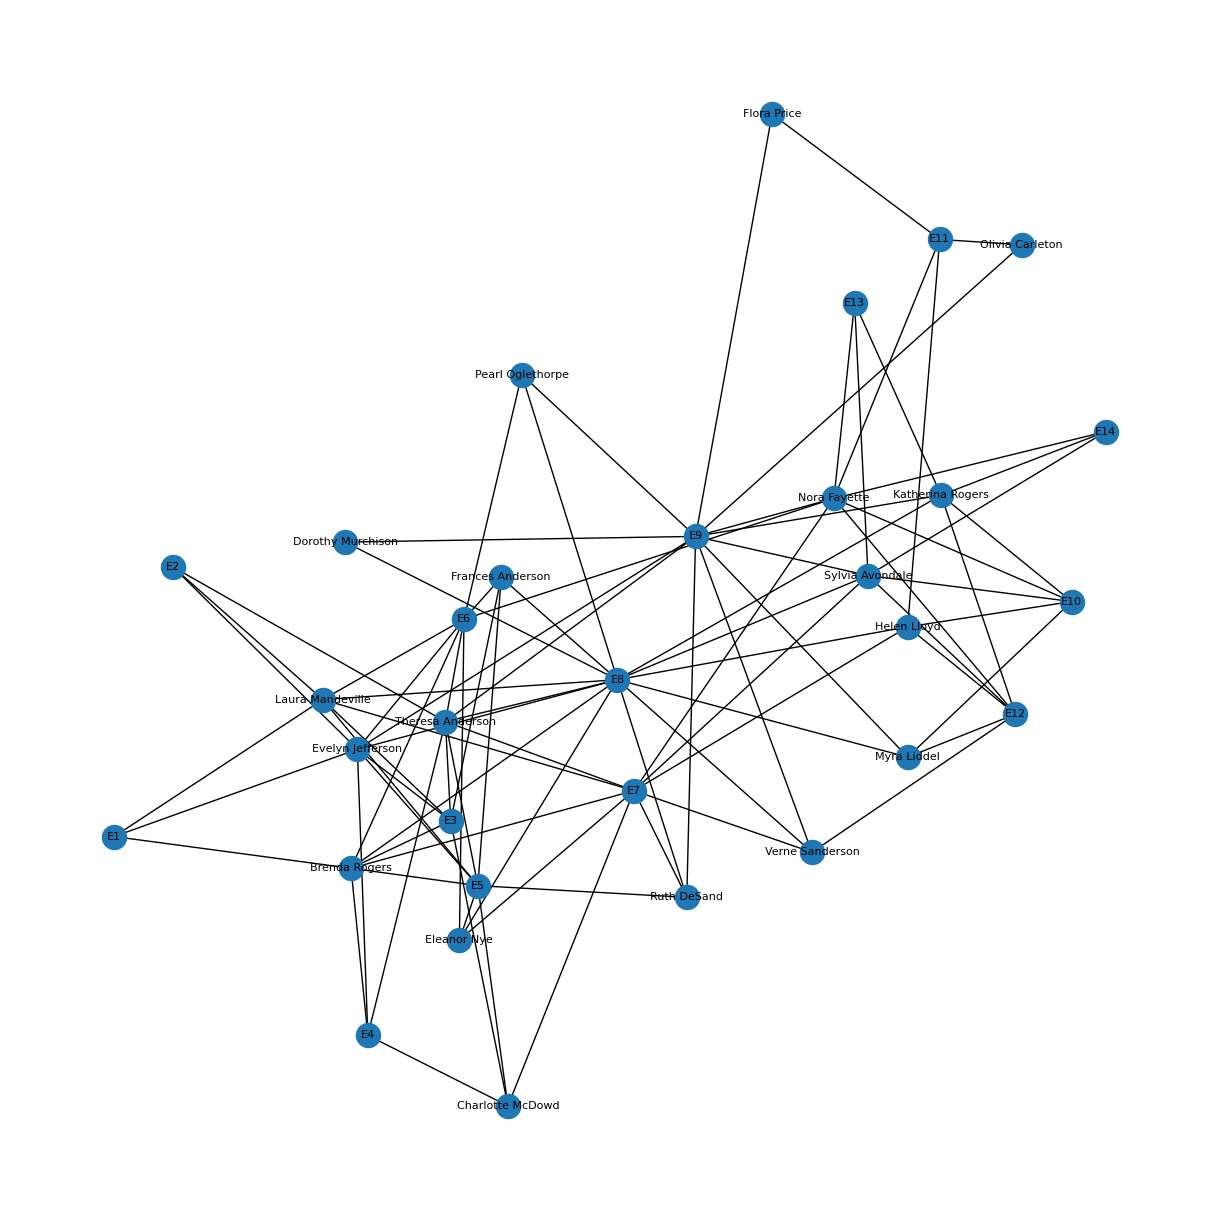

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import bipartite

G = nx.davis_southern_women_graph()
women = G.graph["top"]
clubs = G.graph["bottom"]

print("Biadjacency matrix")
print(bipartite.biadjacency_matrix(G, women, clubs))

# project bipartite graph onto women nodes
W = bipartite.projected_graph(G, women)
print()
print("#Friends, Member")
for w in women:
    print(f"{W.degree(w)} {w}")

# project bipartite graph onto women nodes keeping number of co-occurrence
# the degree computed is weighted and counts the total number of shared contacts
W = bipartite.weighted_projected_graph(G, women)
print()
print("#Friend meetings, Member")
for w in women:
    print(f"{W.degree(w, weight='weight')} {w}")

# Increase spacing
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.5, seed=648)  # Seed layout for reproducible node positions
nx.draw(G, pos, with_labels=True, font_size=8, node_size=300)
plt.show()

# Bipartite & Adjacency Matrix

To begin our analysis, we convert the bipartite graph into an adjency matrix. We can detect alot of sparsity in the matrix.

In [2]:
import pandas as pd

# Create biadjacency matrix and convert it to array
bi_matrix = bipartite.biadjacency_matrix(G, women, clubs).toarray()

# Create datafram with women as rows and clubs as columns
df_bipartite = pd.DataFrame(bi_matrix, index=women, columns=clubs)

# Display the table
display(df_bipartite)

,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,E11,E12,E13,E14
Evelyn Jefferson,1,1,1,1,1,1,0,1,1,0,0,0,0,0
Laura Mandeville,1,1,1,0,1,1,1,1,0,0,0,0,0,0
Theresa Anderson,0,1,1,1,1,1,1,1,1,0,0,0,0,0
Brenda Rogers,1,0,1,1,1,1,1,1,0,0,0,0,0,0
Charlotte McDowd,0,0,1,1,1,0,1,0,0,0,0,0,0,0
Frances Anderson,0,0,1,0,1,1,0,1,0,0,0,0,0,0
Eleanor Nye,0,0,0,0,1,1,1,1,0,0,0,0,0,0
Pearl Oglethorpe,0,0,0,0,0,1,0,1,1,0,0,0,0,0
Ruth DeSand,0,0,0,0,1,0,1,1,1,0,0,0,0,0
Verne Sanderson,0,0,0,0,0,0,1,1,1,0,0,1,0,0


# Women's Affiliation Network

We convert the adjacency matrix into a single mode affliations matrix.  We can see the relationship between the women (the number of instances where the women have overlapping club memberships with each other).

In [3]:
# Calculate the women adjacency matrix
df_women_women = df_bipartite.dot(df_bipartite.T)

# Display the single-mode network table for women
display(df_women_women)

,Evelyn Jefferson,Laura Mandeville,Theresa Anderson,Brenda Rogers,Charlotte McDowd,Frances Anderson,Eleanor Nye,Pearl Oglethorpe,Ruth DeSand,Verne Sanderson,Myra Liddel,Katherina Rogers,Sylvia Avondale,Nora Fayette,Helen Lloyd,Dorothy Murchison,Olivia Carleton,Flora Price
Evelyn Jefferson,8,6,7,6,3,4,3,3,3,2,2,2,2,2,1,2,1,1
Laura Mandeville,6,7,6,6,3,4,4,2,3,2,1,1,2,2,2,1,0,0
Theresa Anderson,7,6,8,6,4,4,4,3,4,3,2,2,3,3,2,2,1,1
Brenda Rogers,6,6,6,7,4,4,4,2,3,2,1,1,2,2,2,1,0,0
Charlotte McDowd,3,3,4,4,4,2,2,0,2,1,0,0,1,1,1,0,0,0
Frances Anderson,4,4,4,4,2,4,3,2,2,1,1,1,1,1,1,1,0,0
Eleanor Nye,3,4,4,4,2,3,4,2,3,2,1,1,2,2,2,1,0,0
Pearl Oglethorpe,3,2,3,2,0,2,2,3,2,2,2,2,2,2,1,2,1,1
Ruth DeSand,3,3,4,3,2,2,3,2,4,3,2,2,3,2,2,2,1,1
Verne Sanderson,2,2,3,2,1,1,2,2,3,4,3,3,4,3,3,2,1,1


# Women's Affiliation Network Graph

We visualize the affilation network.  Due to sparsity, it is difficult to detect meaningful patterns in the graph.  Several of the women (nodes) appears to have more connections (weight), but that is also not obvious.

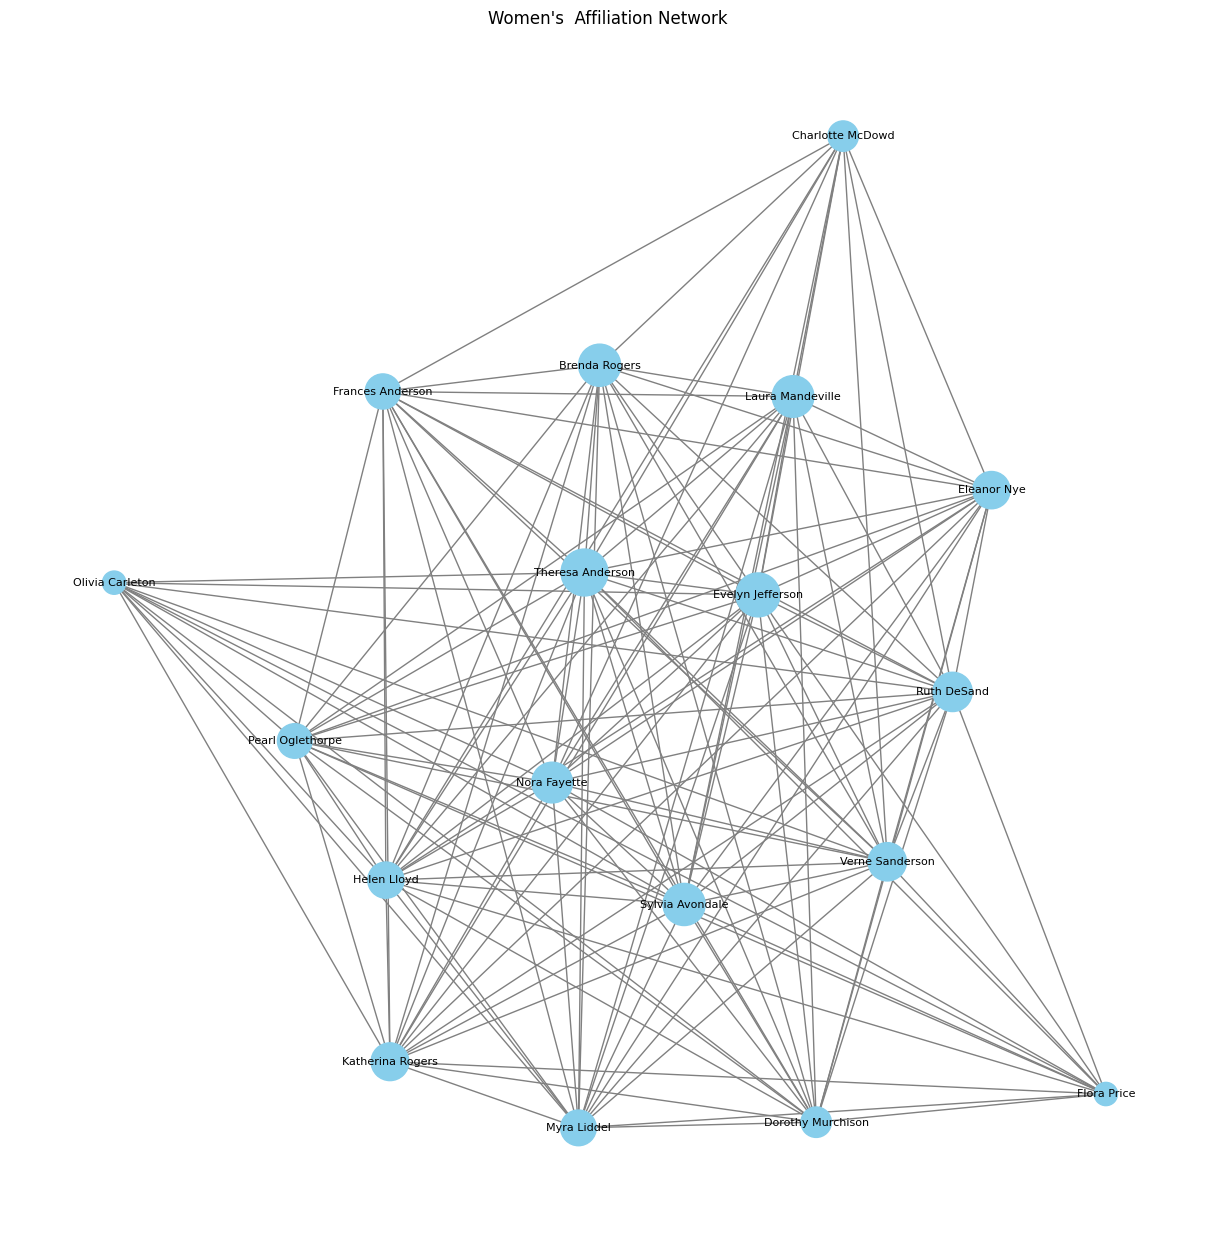

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

# Create adjacency matrix
G_women = nx.from_pandas_adjacency(df_women_women)

# Remove self-loops
G_women.remove_edges_from(nx.selfloop_edges(G_women))

# Calculate node sizes (weighted degree)
node_sizes = [G_women.degree(node, weight='weight') * 20 for node in G_women.nodes()]

# Set up the figure size
plt.figure(figsize=(12, 12))

# Set llayout for the nodes
pos_women = nx.spring_layout(G_women, k=0.8, seed=42)

# Draw and plot the network
nx.draw(G_women, pos_women, with_labels=True, node_color='skyblue', edge_color='gray', node_size=node_sizes, font_size=8, font_weight='light')
plt.title("Women's  Affiliation Network ", fontsize=12)
plt.show()

# Centrality Metrics - Degree, Betweenness, Closeness, Eigenvector

We calculate and sort the centrality metrics for the women nodes.  We note that several of the women have perfect scores of 1.0 - indicating complete connection,  representing the core network.

In [5]:
import pandas as pd
import networkx as nx

# Calculate centrality metrics
degree_cent = nx.degree_centrality(G_women)
betweenness_cent = nx.betweenness_centrality(G_women)
closeness_cent = nx.closeness_centrality(G_women)
eigenvector_cent = nx.eigenvector_centrality(G_women, max_iter=1000)

# Combine in df
metrics_df = pd.DataFrame({
    'Degree Centrality': pd.Series(degree_cent),
    'Betweenness Centrality': pd.Series(betweenness_cent),
    'Closeness Centrality': pd.Series(closeness_cent),
    'Eigenvector Centrality': pd.Series(eigenvector_cent)})

# Sort
metrics_df = metrics_df.sort_values(by='Degree Centrality', ascending=False)

# Display the table
display(metrics_df)

,Degree Centrality,Betweenness Centrality,Closeness Centrality,Eigenvector Centrality
Evelyn Jefferson,1.000000,0.010122,1.000000,0.253524
Theresa Anderson,1.000000,0.010122,1.000000,0.253524
Sylvia Avondale,1.000000,0.010122,1.000000,0.253524
Verne Sanderson,1.000000,0.010122,1.000000,0.253524
Ruth DeSand,1.000000,0.010122,1.000000,0.253524
Nora Fayette,1.000000,0.010122,1.000000,0.253524
Helen Lloyd,1.000000,0.010122,1.000000,0.253524
Myra Liddel,0.941176,0.005348,0.944444,0.243157
Katherina Rogers,0.941176,0.005348,0.944444,0.243157
Pearl Oglethorpe,0.941176,0.005348,0.944444,0.243157


# Women's Affiliation Sociogram

We plot a sociogram to further understand the relationship. We note that there is core 'clique' or subgraph of women that are completely connected (in Yellow). Because their Betweenness scores are identical, there is no single individual that bottlenecks information, but a rather a group of women where the informations flows between the peripherey nodes.

The similar eigenvector values (same sized eigenvector nodes) indicate no individual women has structural influence over the network; rather, its seems influence is uniform and evenly distributed.


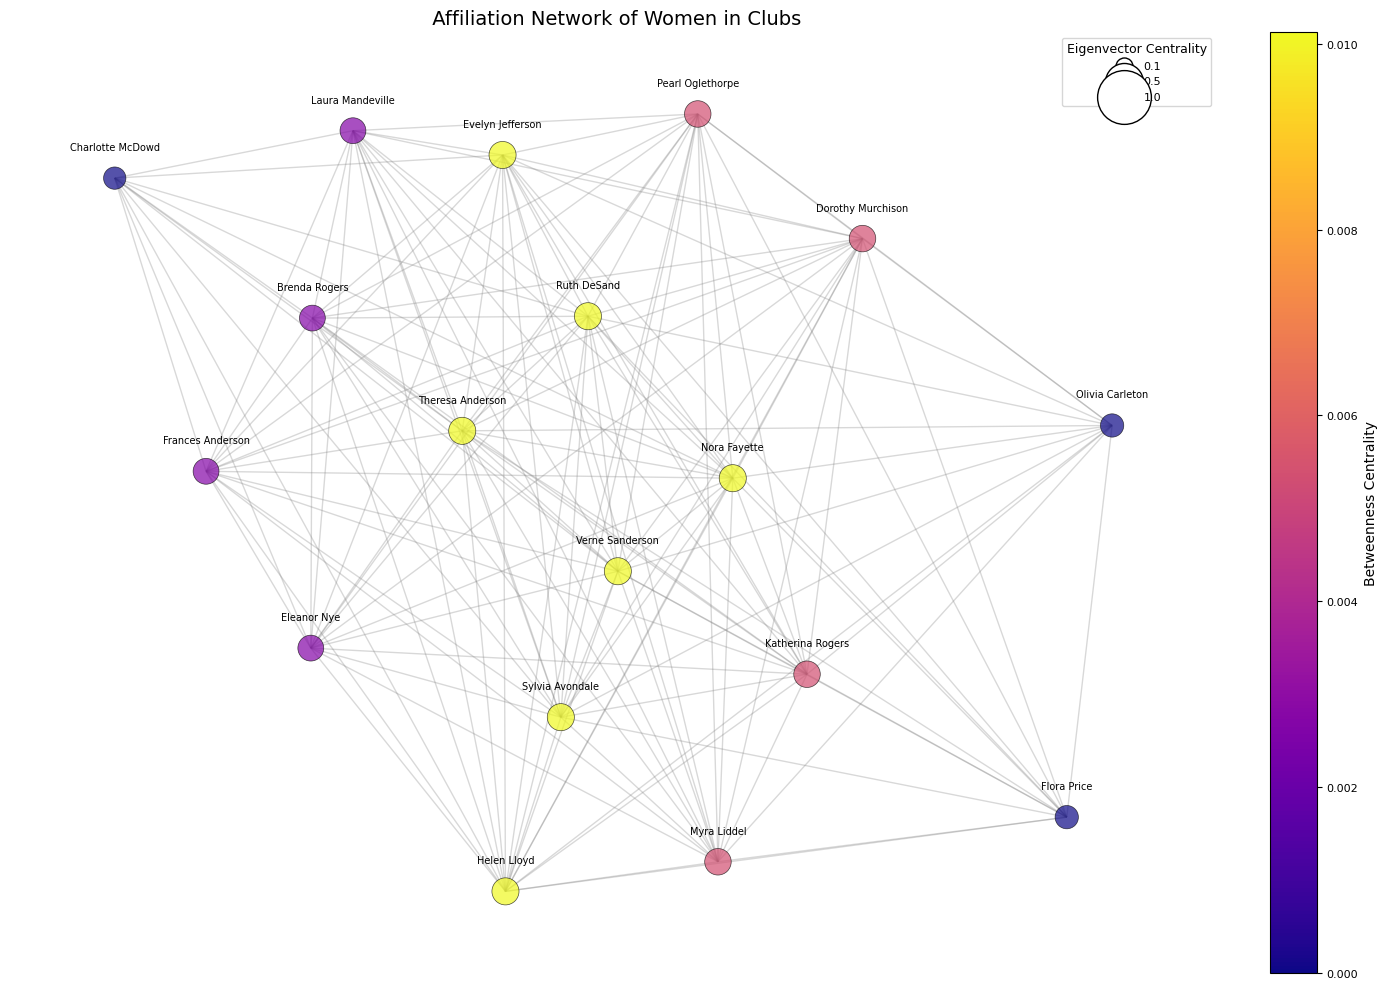

In [6]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Calculate layout
pos = nx.spring_layout(G_women, seed=42)
pos_labels = {node: (coords[0], coords[1] + 0.04) for node, coords in pos.items()}

# Set up the visualization
plt.figure(figsize=(14, 10))
plt.axis('off')
plt.title(' Affiliation Network of Women in Clubs', fontsize=14)

# Compile ordered lists for vectorization
ordered_nodes = list(G_women.nodes())

# Map Node Size to Eigenvector Centrality
node_sizes = [metrics_df.loc[node, 'Eigenvector Centrality'] * 1500 for node in ordered_nodes]

# Map Node Color to Betweenness Centrality
norm = mcolors.Normalize(vmin=metrics_df['Betweenness Centrality'].min(), vmax=metrics_df['Betweenness Centrality'].max())
cmap = plt.cm.plasma
node_colors = [cmap(norm(metrics_df.loc[node, 'Betweenness Centrality'])) for node in ordered_nodes]

# Draw edges
nx.draw_networkx_edges(G_women, pos, alpha=0.3, edge_color='grey')

# Draw nodes vectorized
nx.draw_networkx_nodes(G_women, pos,
                       nodelist=ordered_nodes,
                       node_size=node_sizes,
                       node_color=node_colors,
                       alpha=0.7,
                       edgecolors='black',
                       linewidths=0.5)

# Draw labels
nx.draw_networkx_labels(G_women, pos_labels, font_size=7, font_weight='light', font_color='black')

#  Add legends

# Add Size Legend
sizes = [0.1, 0.5, 1.0]
scaled_sizes = [s * 1500 for s in sizes]
l1 = plt.scatter([], [], s=scaled_sizes[0], c='white', edgecolors='black')
l2 = plt.scatter([], [], s=scaled_sizes[1], c='white', edgecolors='black')
l3 = plt.scatter([], [], s=scaled_sizes[2], c='white', edgecolors='black')
labels = ['0.1', '0.5', '1.0']
plt.legend([l1, l2, l3], labels, title="Eigenvector Centrality", loc='upper right', frameon=True, fontsize=8, title_fontsize=9)

# Add Color Legend
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('Betweenness Centrality', fontsize=10)
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

# Centrality Metrics Stacked Bar Chart

The plot allows us to confirm two key attributes of the women.  The groups appears to be stratified. The total network can be broken down in subgroups of women that have similar centrality metrics within the group.

The almost complete lack of Betweenness confirms no central information or gatekeeper, signaling a resiliant network (ie, the removal of one woman will not disrupt the network).

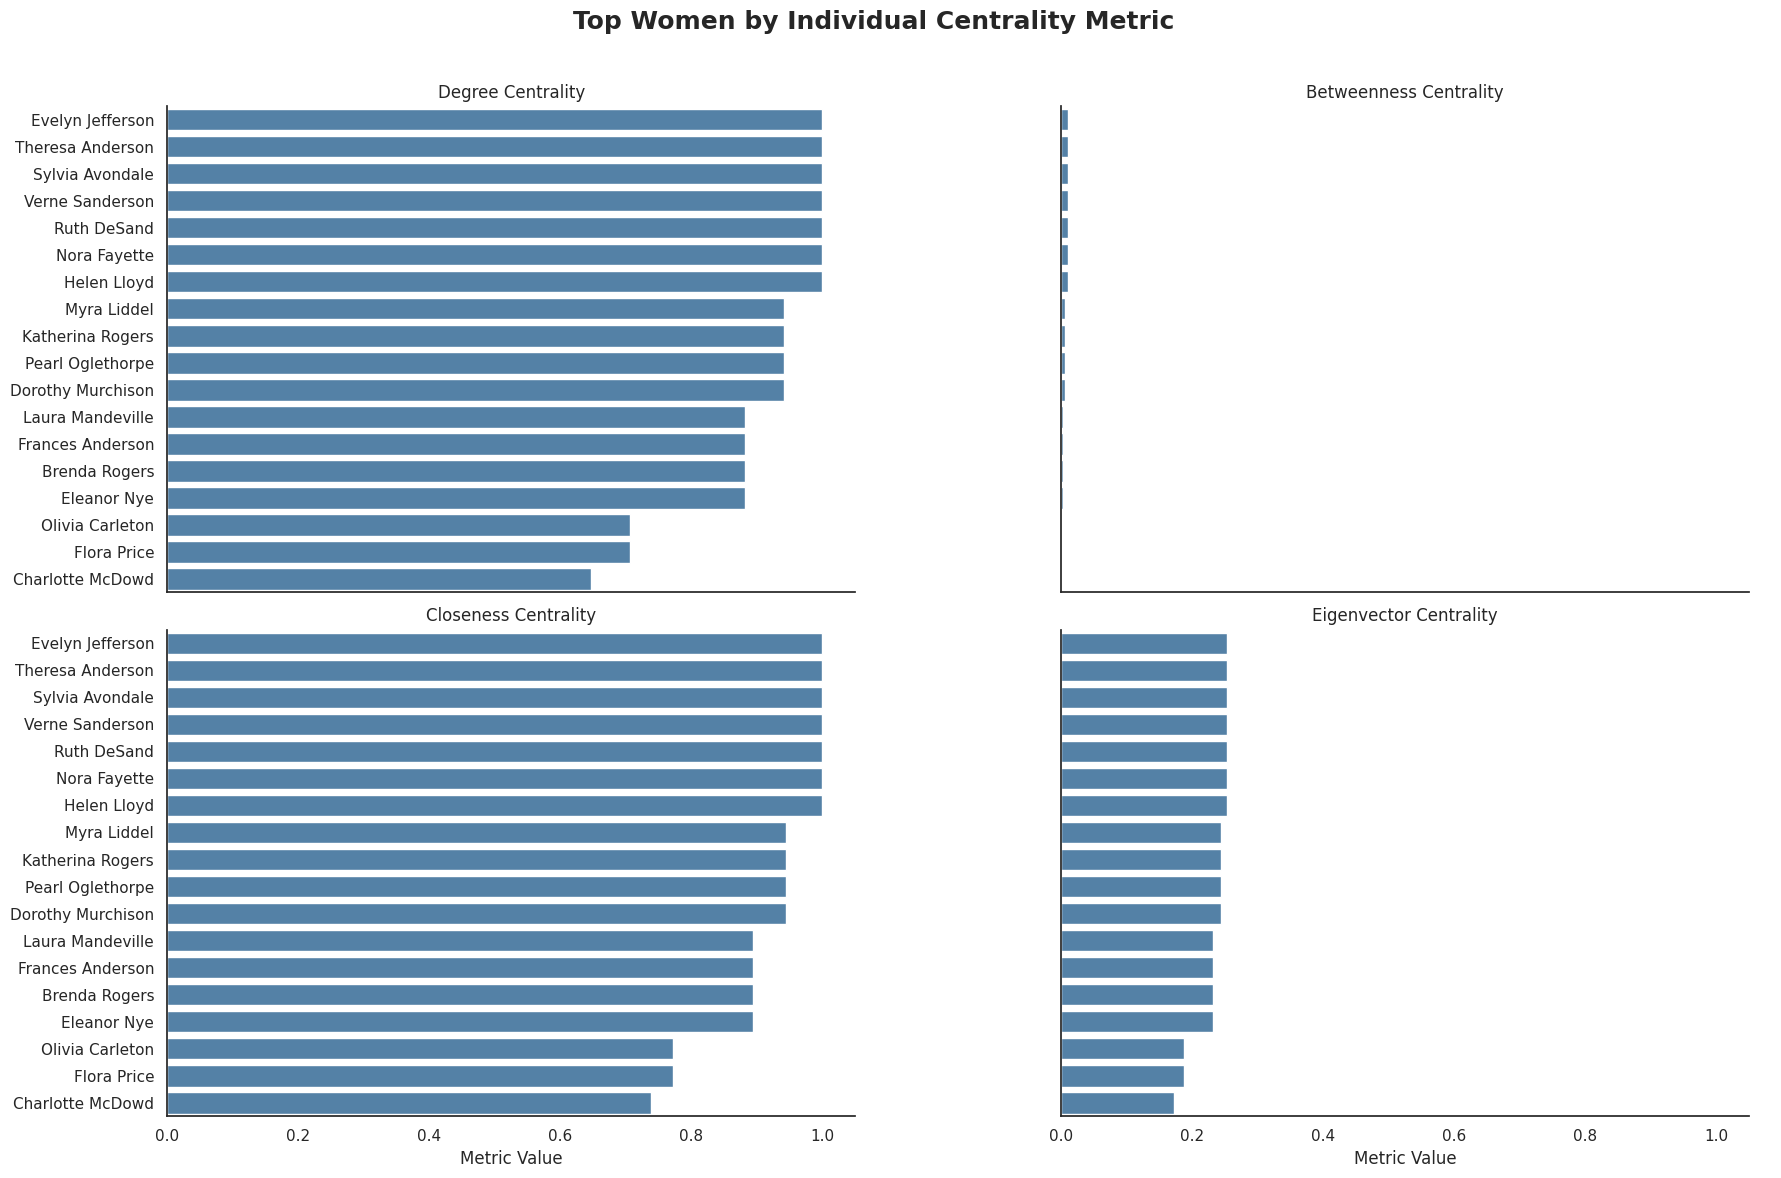

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Transform metrics_df into long format
metrics_reset = metrics_df.reset_index().rename(columns={'index': 'Name'})
metrics_long = pd.melt(metrics_reset, id_vars=['Name'], var_name='Metric', value_name='Value')

# Sort
unique_names_in_order = metrics_df.index.tolist()

# Create a faceted horizontal bar chart
sns.set_theme(style="white")

g_bar = sns.catplot(
    data=metrics_long,
    y='Name', x='Value', col='Metric',
    kind='bar',
    col_wrap=2,
    height=6,
    aspect=1.5,
    order=unique_names_in_order,
    color='steelblue'
)

# Customize titles and axes
g_bar.set_titles("{col_name}", fontsize=14, weight='light')
g_bar.set_axis_labels("Metric Value", "", fontsize=12)

# Adjust the overall layout
plt.subplots_adjust(top=0.9, wspace=0.3)
g_bar.fig.suptitle('Top Women by Individual Centrality Metric', fontsize=18, weight='bold')

plt.show()

# Club Affiliation Network

We convert the adjacency matrix into a single mode affliations matrix.  We can see the relationship between the clubs (the number of instances where clubs have overlapping members with each other).

In [8]:
import pandas as pd

# Create the biparte dataframe
club_matrix = df_bipartite.T.dot(df_bipartite)

# Display the club affiliation table
display(club_matrix)

,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,E11,E12,E13,E14
E1,3,2,3,2,3,3,2,3,1,0,0,0,0,0
E2,2,3,3,2,3,3,2,3,2,0,0,0,0,0
E3,3,3,6,4,6,5,4,5,2,0,0,0,0,0
E4,2,2,4,4,4,3,3,3,2,0,0,0,0,0
E5,3,3,6,4,8,6,6,7,3,0,0,0,0,0
E6,3,3,5,3,6,8,5,7,4,1,1,1,1,1
E7,2,2,4,3,6,5,10,8,5,3,2,4,2,2
E8,3,3,5,3,7,7,8,14,9,4,1,5,2,2
E9,1,2,2,2,3,4,5,9,12,4,3,5,3,3
E10,0,0,0,0,0,1,3,4,4,5,2,5,3,3


# Clubs Affiliation Network Graph

We visualize the affilation network.  Due to sparsity, it is difficult to detect meaningful patterns in the graph.  Several of the clubs (nodes) appear to have more connections (weight), but that is also not obvious.

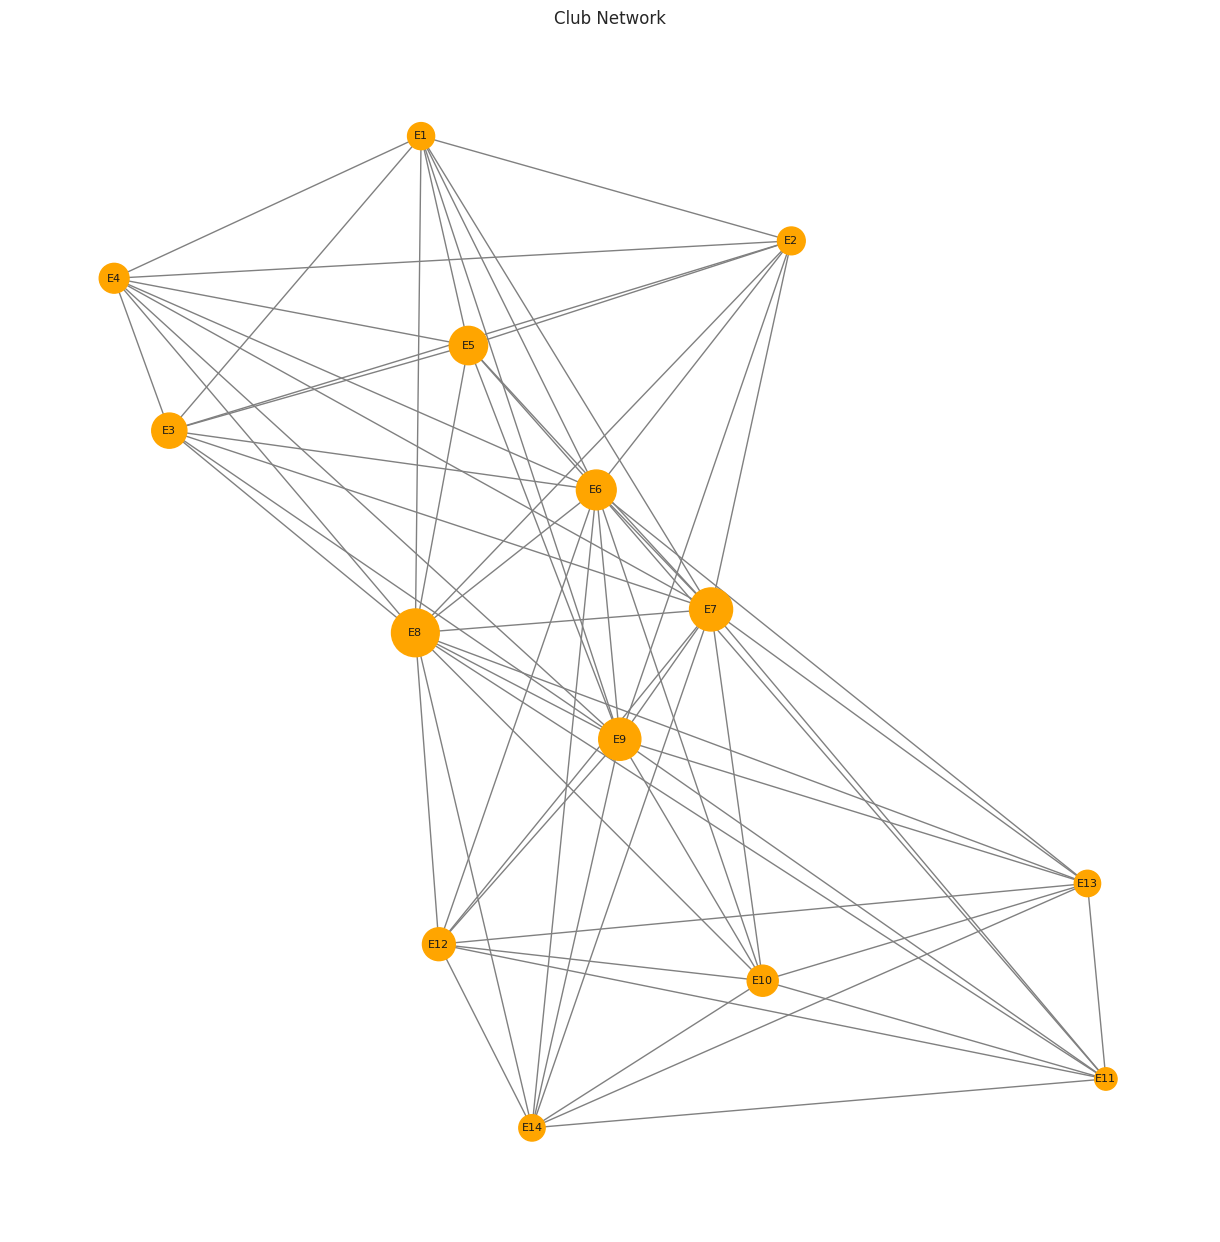

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

# Create adjacency matrix for clubs
G_clubs = nx.from_pandas_adjacency(club_matrix)

# Remove self-loops
G_clubs.remove_edges_from(nx.selfloop_edges(G_clubs))

# Calculate node sizes (weighted degree)
node_sizes = [G_clubs.degree(node, weight='weight') * 20 for node in G_clubs.nodes()]

# Set up the figure size
plt.figure(figsize=(12, 12))

# Generate a layout for the nodes
pos_clubs = nx.spring_layout(G_clubs, k=0.8, seed=42)

# Draw the network
nx.draw(G_clubs, pos_clubs, with_labels=True, node_color='orange', edge_color='gray', node_size=node_sizes, font_size=8, font_weight='light')

# Add a title and show the plot
plt.title("Club Network", fontsize=12)
plt.show()

In [10]:
import pandas as pd
import networkx as nx

# Calculate centrality metrics for the club network
degree_cent = nx.degree_centrality(G_clubs)
betweenness_cent = nx.betweenness_centrality(G_clubs)
closeness_cent = nx.closeness_centrality(G_clubs)
eigenvector_cent = nx.eigenvector_centrality(G_clubs, max_iter=1000)

# Combine into DataFrame
club_metrics_df = pd.DataFrame({
    'Degree Centrality': pd.Series(degree_cent),
    'Betweenness Centrality': pd.Series(betweenness_cent),
    'Closeness Centrality': pd.Series(closeness_cent),
    'Eigenvector Centrality': pd.Series(eigenvector_cent)
})

# Sort by Degree Centrality
club_metrics_df = club_metrics_df.sort_values(by='Degree Centrality', ascending=False)

# Display the table
display(club_metrics_df)

,Degree Centrality,Betweenness Centrality,Closeness Centrality,Eigenvector Centrality
E6,1.000000,0.080128,1.000000,0.339336
E7,1.000000,0.080128,1.000000,0.339336
E8,1.000000,0.080128,1.000000,0.339336
E9,1.000000,0.080128,1.000000,0.339336
E2,0.615385,0.000000,0.722222,0.232251
E1,0.615385,0.000000,0.722222,0.232251
E5,0.615385,0.000000,0.722222,0.232251
E4,0.615385,0.000000,0.722222,0.232251
E3,0.615385,0.000000,0.722222,0.232251
E10,0.615385,0.000000,0.722222,0.232251


# Clubs Affiliation Sociogram

We plot a sociogram to further understand the relationship between the clubs. We note that there is core subgraph of clubs that are highly connected (in yellow). Because their Betweenness scores are identical, the four nodes represent th 4 clubs where the information flow between the peripheray nodes.

The similar eigenvector values (same sized eigenvector nodes) indicate no individual club has structural influence over the network; rather, its seems influence is uniform and evenly distributed.

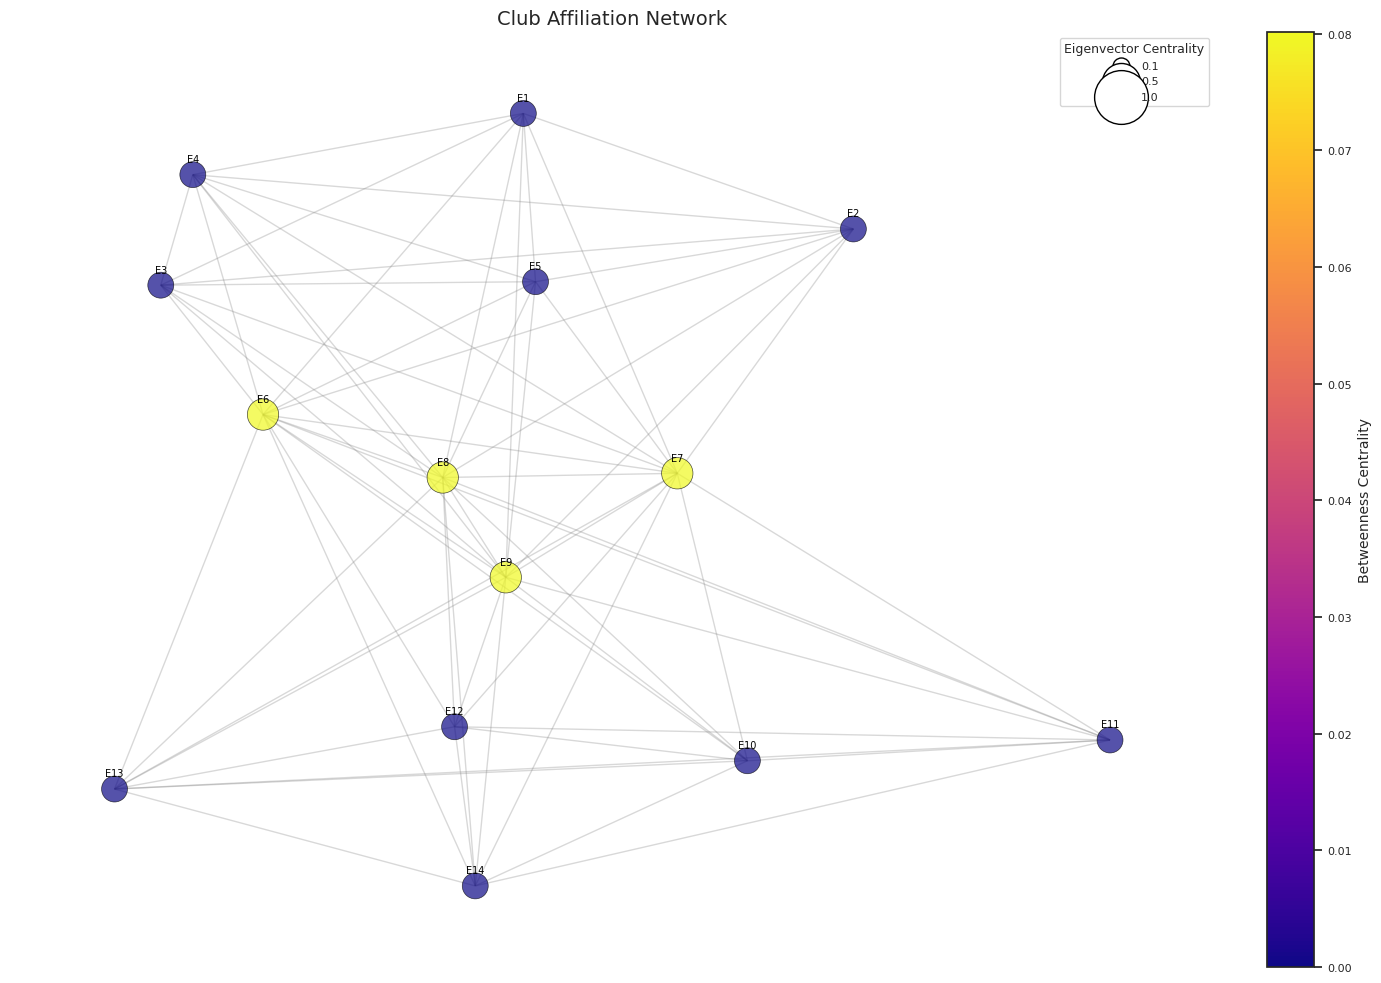

In [11]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Calculate layout
pos_clubs = nx.spring_layout(G_clubs, seed=42)

# Calculate offset positions for labela
pos_labels = {node: (coords[0], coords[1] + 0.04) for node, coords in pos_clubs.items()}

# Set up the visualization
plt.figure(figsize=(14, 10))
plt.axis('off')
plt.title('Club Affiliation Network', fontsize=14)

# Compile ordered lists for vectorization
ordered_nodes = list(G_clubs.nodes())

# Map Node Size to Eigenvector Centrality
node_sizes = [club_metrics_df.loc[node, 'Eigenvector Centrality'] * 1500 for node in ordered_nodes]

# Map Node Color to Betweenness Centrality
norm = mcolors.Normalize(vmin=club_metrics_df['Betweenness Centrality'].min(), vmax=club_metrics_df['Betweenness Centrality'].max())
cmap = plt.cm.plasma
node_colors = [cmap(norm(club_metrics_df.loc[node, 'Betweenness Centrality'])) for node in ordered_nodes]

# Draw edges with transparency
nx.draw_networkx_edges(G_clubs, pos_clubs, alpha=0.3, edge_color='grey')

# 2. Draw nodes vectorized

nx.draw_networkx_nodes(G_clubs, pos_clubs,
                       nodelist=ordered_nodes,
                       node_size=node_sizes,
                       node_color=node_colors,
                       alpha=0.7,
                       edgecolors='black',
                       linewidths=0.5)

# 3. Draw labels
nx.draw_networkx_labels(G_clubs, pos_labels, font_size=7, font_weight='light', font_color='black')

# 4. Add legends

# Add Size Legend (Eigenvector Centrality)
sizes = [0.1, 0.5, 1.0]
scaled_sizes = [s * 1500 for s in sizes]
l1 = plt.scatter([], [], s=scaled_sizes[0], c='white', edgecolors='black')
l2 = plt.scatter([], [], s=scaled_sizes[1], c='white', edgecolors='black')
l3 = plt.scatter([], [], s=scaled_sizes[2], c='white', edgecolors='black')
labels = ['0.1', '0.5', '1.0']
plt.legend([l1, l2, l3], labels, title="Eigenvector Centrality", loc='upper right', frameon=True, fontsize=8, title_fontsize=9)

# Add Color Legend (Betweenness Centrality)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('Betweenness Centrality', fontsize=10)
cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

# Centrality Metrics Stacked Bar Chart

The plot allows us to confirm two key attributes of the clubs.  The total network can be broken down into two subgroups of clubs that have similar centrality metrics within the group. The core subgroup connects the core subgroup of women.

The almost complete lack of Betweenness confirms no central information or gatekeeper, signaling a resiliant network (ie, the removal of one woman will not disrupt the network).

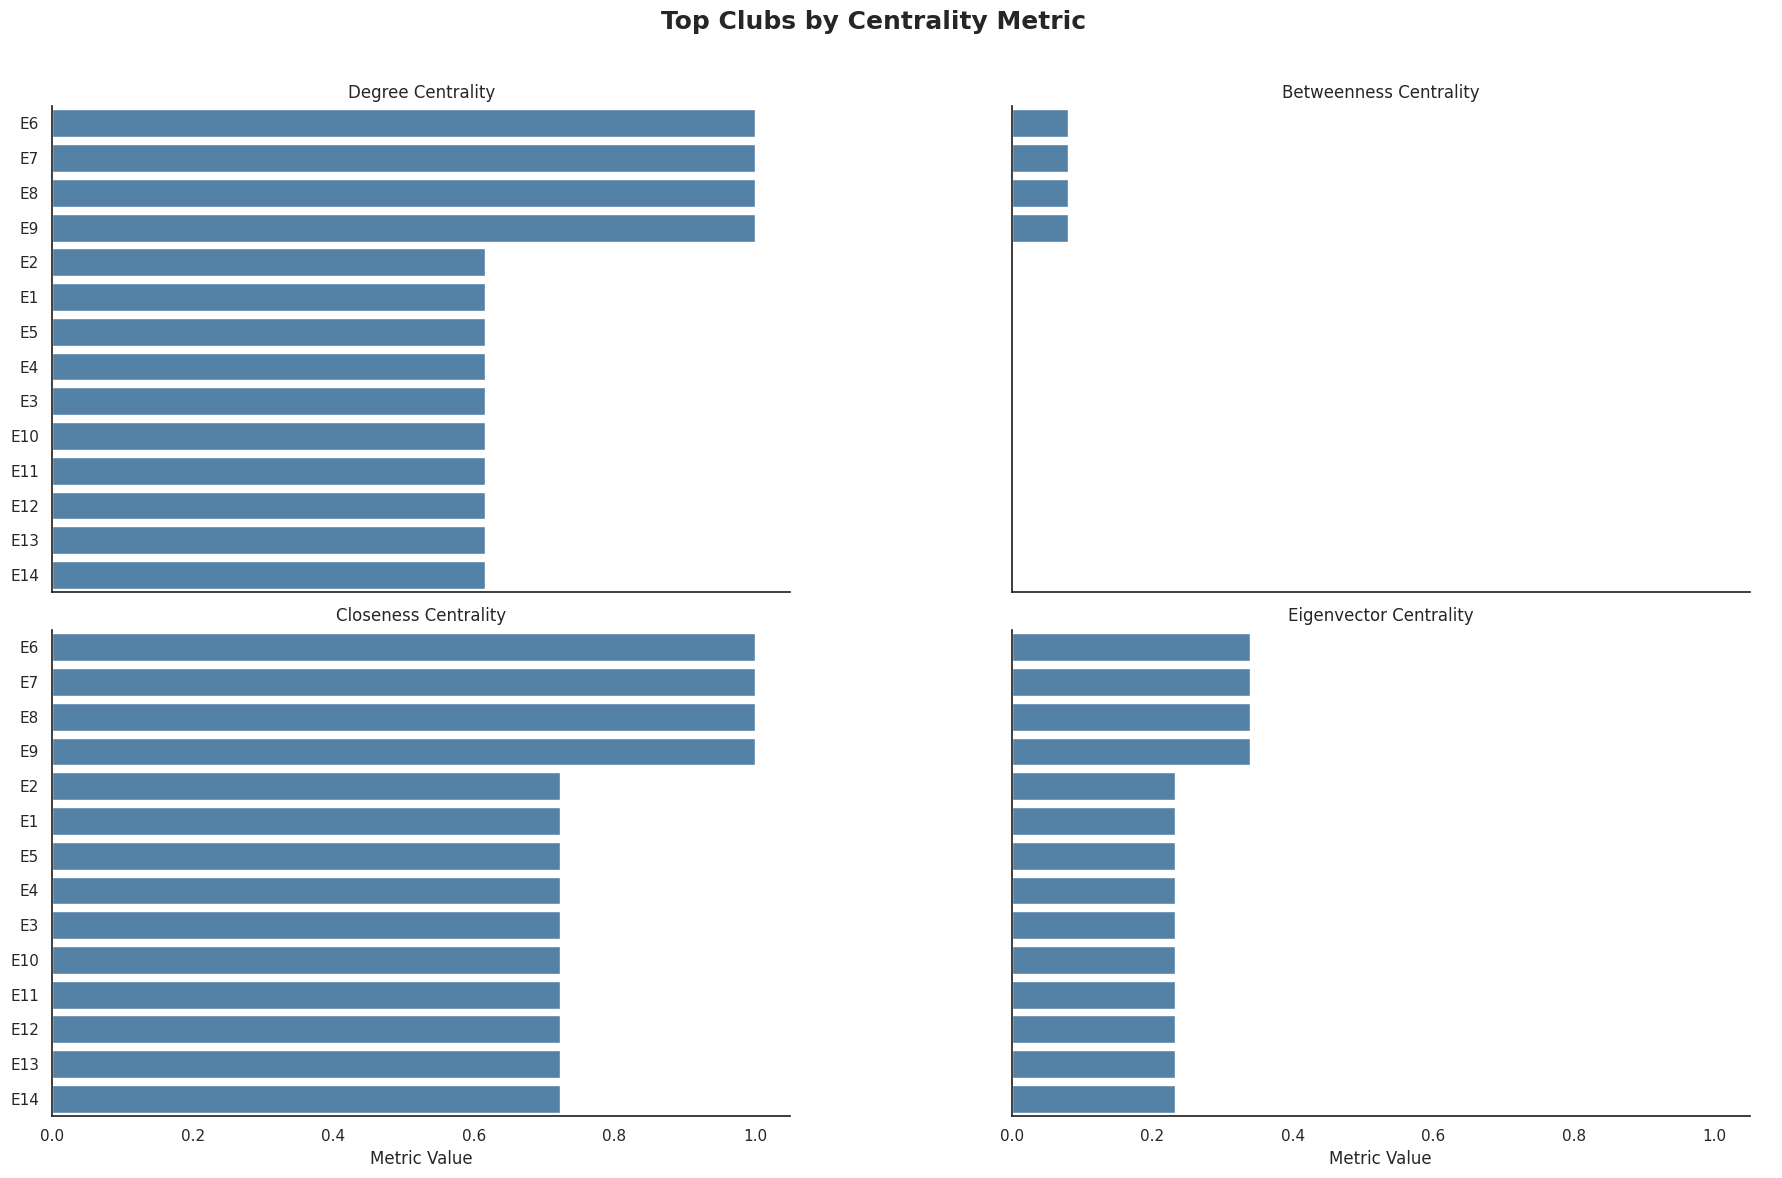

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Transform club_metrics_df into long format
club_metrics_reset = club_metrics_df.reset_index().rename(columns={'index': 'Club Name'})
club_metrics_long = pd.melt(club_metrics_reset, id_vars=['Club Name'], var_name='Metric', value_name='Value')

# Maintain the original sorted order
unique_clubs_in_order = club_metrics_df.index.tolist()

# Create a faceted horizontal bar chart
sns.set_theme(style="white")

g_bar = sns.catplot(
    data=club_metrics_long,
    y='Club Name', x='Value', col='Metric',
    kind='bar',
    col_wrap=2,
    height=6,
    aspect=1.5,
    order=unique_clubs_in_order,
    color='steelblue'
)

# Customize titles and axes
g_bar.set_titles("{col_name}", fontsize=14, weight='light')
g_bar.set_axis_labels("Metric Value", "", fontsize=12)

# Adjust the layout
plt.subplots_adjust(top=0.9, wspace=0.3)
g_bar.fig.suptitle('Top Clubs by Centrality Metric', fontsize=18, weight='bold')

plt.show()